In [1]:
%pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

### Data Loading and Exploration

In [3]:
bike_sharing_dataset = fetch_ucirepo(id=275)
print(bike_sharing_dataset)

{'data': {'ids':        instant
0            1
1            2
2            3
3            4
4            5
...        ...
17374    17375
17375    17376
17376    17377
17377    17378
17378    17379

[17379 rows x 1 columns], 'features':            dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0      2011-01-01       1   0     1   0        0        6           0   
1      2011-01-01       1   0     1   1        0        6           0   
2      2011-01-01       1   0     1   2        0        6           0   
3      2011-01-01       1   0     1   3        0        6           0   
4      2011-01-01       1   0     1   4        0        6           0   
...           ...     ...  ..   ...  ..      ...      ...         ...   
17374  2012-12-31       1   1    12  19        0        1           1   
17375  2012-12-31       1   1    12  20        0        1           1   
17376  2012-12-31       1   1    12  21        0        1           1   
17377  2012-12-31       1   1    1

In [4]:
x = bike_sharing_dataset.data.features
y = bike_sharing_dataset.data.targets

In [ ]:
original_data = bike_sharing_dataset.data.original
print(bike_sharing_dataset.metadata)
print(bike_sharing_dataset.variables)

# Extract hourly and daily data with user type breakdown
hour_data = x.copy()
hour_data["cnt"] = y["cnt"].values if "cnt" in y.columns else y.values
hour_data["casual"] = original_data["casual"].values
hour_data["registered"] = original_data["registered"].values

print(f"Hourly data loaded: {hour_data.shape}")
print(f"Columns: {list(hour_data.columns)}")


{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

In [6]:
# For daily data analysis, aggregate the hourly data
day_data = (
    hour_data.groupby("dteday")
    .agg(
        {
            "season": "first",
            "yr": "first",
            "mnth": "first",
            "holiday": "first",
            "weekday": "first",
            "workingday": "first",
            "weathersit": "mean",
            "temp": "mean",
            "atemp": "mean",
            "hum": "mean",
            "windspeed": "mean",
            "casual": "sum",
            "registered": "sum",
            "cnt": "sum",
        }
    )
    .reset_index()
)

print(f"Daily data aggregated: {day_data.shape}")
day_data_sorted = day_data.sort_values("dteday").reset_index(drop=True)
day_data_sorted["dteday"] = pd.to_datetime(day_data_sorted["dteday"])
print(f"Daily data sorted by date: {day_data_sorted.shape}")

Daily data aggregated: (731, 15)
Daily data sorted by date: (731, 15)


### Constraints Derivation

#

Daily data aggregated

In [7]:
for col in day_data.columns:
    min_val = day_data[col].min()
    max_val = day_data[col].max()
    dtype = day_data[col].dtype
    print(f"{col:15} | Range: [{min_val:7}, {max_val:7}] | Type: {dtype}")

dteday          | Range: [2011-01-01, 2012-12-31] | Type: object
season          | Range: [      1,       4] | Type: int64
yr              | Range: [      0,       1] | Type: int64
mnth            | Range: [      1,      12] | Type: int64
holiday         | Range: [      0,       1] | Type: int64
weekday         | Range: [      0,       6] | Type: int64
workingday      | Range: [      0,       1] | Type: int64
weathersit      | Range: [    1.0,     3.0] | Type: float64
temp            | Range: [0.0591304347826087, 0.8616666666666667] | Type: float64
atemp           | Range: [0.07906956521739131, 0.8408958333333333] | Type: float64
hum             | Range: [    0.0,  0.9725] | Type: float64
windspeed       | Range: [0.022391666666666667, 0.5074625] | Type: float64
casual          | Range: [      2,    3410] | Type: int64
registered      | Range: [     20,    6946] | Type: int64
cnt             | Range: [     22,    8714] | Type: int64


TOTAL Demand Constraints (bikes/hour): 

In [ ]:
min_hourly_demand = hour_data["cnt"].min()
max_hourly_demand = hour_data["cnt"].max()
avg_hourly_demand = hour_data["cnt"].mean()
std_hourly_demand = hour_data["cnt"].std()
print(f"Min: {min_hourly_demand}")
print(f"Max: {max_hourly_demand}")
print(f"Avg: {avg_hourly_demand:.2f}")
print(f"Std Dev: {std_hourly_demand:.2f}")

Min: 1
Max: 977
Avg: 189.46
Std Dev: 181.39


USER Type Demand Constraints:

Casual

In [ ]:
min_casual = hour_data["casual"].min()
max_casual = hour_data["casual"].max()
avg_casual = hour_data["casual"].mean()
print(f"Range: [{min_casual}, {max_casual}] | Avg: {avg_casual:.2f} bikes/hour")


Range: [0, 367] | Avg: 35.68 bikes/hour


Registered

In [ ]:
min_registered = hour_data["registered"].min()
max_registered = hour_data["registered"].max()
avg_registered = hour_data["registered"].mean()
print(
    f"Range: [{min_registered}, {max_registered}] | Avg: {avg_registered:.2f} bikes/hour"
)

Range: [0, 886] | Avg: 153.79 bikes/hour


User Distribution

In [ ]:
print(f"Casual %:     {100 * avg_casual / avg_hourly_demand:.1f}%")
print(f"Registered %: {100 * avg_registered / avg_hourly_demand:.1f}%")


Casual %:     18.8%
Registered %: 81.2%


User type ratio analysis

In [ ]:
print("User Type Ratios by Hour:")
casual_registered_ratio = (
    hour_data.groupby("hr")["casual"].mean()
    / hour_data.groupby("hr")["registered"].mean()
)
print(casual_registered_ratio)


User Type Ratios by Hour:
hr
0     0.232247
1     0.242046
2     0.263679
3     0.301385
4     0.245920
5     0.076383
6     0.057891
7     0.054997
8     0.064268
9     0.163951
10    0.365413
11    0.400670
12    0.369113
13    0.398719
14    0.456931
15    0.424807
16    0.309544
17    0.191834
18    0.167735
19    0.185614
20    0.190907
21    0.196138
22    0.203999
23    0.209263
dtype: float64


#### Data-Driven Methods

##### Standard Deviation Method (Gaussian Assumption)

$$C = \mu + k\sigma$$

where:
- $C$ = Capacity
- $\mu$ = Mean
- $k$ = Standard deviation multiplier (scaling factor)
- $\sigma$ = Standard deviation


##### Theoretical Foundation: Safety Stock Theory

**Reference:** [1] J. N. C. Gonçalves, M. Sameiro Carvalho, and P. Cortez, "Operations research models and methods for safety stock determination: A review," *Operations Research Perspectives*, vol. 7, no. 1, p. 100164, 2020. doi: 10.1016/j.orp.2020.100164.

In [13]:
confidence_factors = {1: "68% confidence", 2: "95% confidence", 3: "99.7% confidence"}
for k, desc in confidence_factors.items():
    capacity_std = avg_hourly_demand + k * std_hourly_demand
    safety_buffer_std = capacity_std / max_hourly_demand
    print(
        f" k={k} ({desc}): capacity = {capacity_std:.0f} bikes -> buffer = {safety_buffer_std:.2f}x"
    )

 k=1 (68% confidence): capacity = 371 bikes -> buffer = 0.38x
 k=2 (95% confidence): capacity = 552 bikes -> buffer = 0.57x
 k=3 (99.7% confidence): capacity = 734 bikes -> buffer = 0.75x


#### Mean-Percentile Method (Non-Parametric)
- Calculate the mean demand ($\mu$).
- Determine the desired service level.
- Find the corresponding percentile demand ($P_k$) from the historical data.
- Set capacity $C$ to the percentile demand: $C = P_k$.

**Reference:** [2] D. Gmach, J. Rolia, L. Cherkasova, and A. Kemper, "Capacity management and demand prediction for next generation data centers," in *Proc. IEEE International Conference on Web Services (ICWS 2007)*, 2007, pp. 43–50. doi: 10.1109/ICWS.2007.62.

In [14]:
percentiles = [90, 95, 99]
percentile_buffers = {}
for p in percentiles:
    p_value = np.percentile(hour_data["cnt"], p)
    buffer_p = p_value / max_hourly_demand
    percentile_buffers[p] = buffer_p
    print(f" {p}th percentile: {p_value:.0f} bikes -> buffer = {buffer_p:.2f}x")


 90th percentile: 451 bikes -> buffer = 0.46x
 95th percentile: 563 bikes -> buffer = 0.58x
 99th percentile: 782 bikes -> buffer = 0.80x


Selected Method: **Mean-Percentile Method**
- Because Handles 563 bikes (0.95 quantile of all hourly demands)
- Best for Highly variable spiky demand patterns

In [ ]:
SAFETY_BUFFER = 0.58

In [ ]:
min_daily_demand = day_data_sorted["cnt"].min()
max_daily_demand = day_data_sorted["cnt"].max()

percentiles = [90, 95, 99]
percentile_buffers_daily = {}
for p in percentiles:
    p_value = np.percentile(day_data_sorted["cnt"], p)
    buffer_p = p_value / max_daily_demand
    percentile_buffers_daily[p] = buffer_p
    print(f"{p}th percentile: {p_value:.0f} bikes -> buffer = {buffer_p:.2f}x")

90th percentile: 7290 bikes -> buffer = 0.84x
95th percentile: 7576 bikes -> buffer = 0.87x
99th percentile: 8164 bikes -> buffer = 0.94x


In [17]:
SAFETY_BUFFER_DAILY = 0.87

#### Logical Constraints:

day relationships

In [18]:
holiday_working = hour_data[
    (hour_data["holiday"] == 1) & (hour_data["workingday"] == 1)
]

weekend_data = hour_data[hour_data["weekday"].isin([0, 6])]
bad_weekend = weekend_data[weekend_data["workingday"] == 1]

print(f"Holiday & Working Day hours: {len(holiday_working)}")
print(f"Weekend hours: {len(weekend_data)}")
print(f"Weekend hours marked as working days: {len(bad_weekend)}")

Holiday & Working Day hours: 0
Weekend hours: 5014
Weekend hours marked as working days: 0


### Time Constraints:

In [19]:
print(f"Time Range: {hour_data['dteday'].min()} to {hour_data['dteday'].max()}")
print(f"Hours per day: {hour_data['hr'].unique()}")
print(
    f"Seasons: {sorted(hour_data['season'].unique())} (1=Spring, 2=Summer, 3=Fall, 4=Winter)"
)
print(f"Years: {sorted(hour_data['yr'].unique())} (0=2011, 1=2012)")
print(f"Months: {sorted(hour_data['mnth'].unique())}")
print(f"Weekdays: {sorted(hour_data['weekday'].unique())} (0=Sunday, 1-6=Mon-Sat)")
print(f"Holiday indicator: {hour_data['holiday'].unique()} (0=No, 1=Yes)")
print(f"Working day indicator: {hour_data['workingday'].unique()} (0=No, 1=Yes)")

Time Range: 2011-01-01 to 2012-12-31
Hours per day: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Seasons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (1=Spring, 2=Summer, 3=Fall, 4=Winter)
Years: [np.int64(0), np.int64(1)] (0=2011, 1=2012)
Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Weekdays: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] (0=Sunday, 1-6=Mon-Sat)
Holiday indicator: [0 1] (0=No, 1=Yes)
Working day indicator: [0 1] (0=No, 1=Yes)


#### Demand Constraints:

In [20]:
hourly_stats = hour_data.groupby("hr")[["cnt", "casual", "registered"]].agg(
    ["mean", "min", "max", "std"]
)
peak_hour = hour_data.groupby("hr")["cnt"].mean().idxmax()
peak_hour_demand = hour_data.groupby("hr")["cnt"].mean().max()
min_hour = hour_data.groupby("hr")["cnt"].mean().idxmin()
min_hour_demand = hour_data.groupby("hr")["cnt"].mean().min()

Total demand constraints (bikes/hour):

In [ ]:
print(f"Peak hour: {int(peak_hour)}:00 with avg {peak_hour_demand:.0f} bikes")
print(f"Lowest hour: {int(min_hour)}:00 with avg {min_hour_demand:.0f} bikes")
print(f"Peak-to-trough ratio: {peak_hour_demand / min_hour_demand:.2f}x")

Peak hour: 17:00 with avg 461 bikes
Lowest hour: 4:00 with avg 6 bikes
Peak-to-trough ratio: 72.64x


Hourly Pattern of CASUAL Users:

In [22]:
casual_by_hour = hour_data.groupby("hr")["casual"].mean()
peak_casual_hour = casual_by_hour.idxmax()


In [23]:
print(
    f"Peak hour: {int(peak_casual_hour)}:00 with avg {casual_by_hour.max():.0f} bikes"
)
print(f"Average: {casual_by_hour.mean():.2f} bikes/hour")

Peak hour: 14:00 with avg 76 bikes
Average: 35.48 bikes/hour


Hourly Pattern of REGISTERED Users:

In [24]:
registered_by_hour = hour_data.groupby("hr")["registered"].mean()
peak_registered_hour = registered_by_hour.idxmax()

In [ ]:
print(
    f"Peak hour: {int(peak_registered_hour)}:00 with avg {registered_by_hour.max():.0f} bikes"
)
print(f"Average: {registered_by_hour.mean():.2f} bikes/hour")

Peak hour: 17:00 with avg 387 bikes
Average: 153.00 bikes/hour


In [ ]:
print(f"Hour {int(peak_hour)}:00 requires more redundancy than hour {int(min_hour)}:00")
print(f"Safety Buffer defined: {SAFETY_BUFFER}x")
print(f"Peak buffer: capacity ≥ {peak_hour_demand * SAFETY_BUFFER:.0f} bikes")

Hour 17:00 requires more redundancy than hour 4:00
Safety Buffer defined: 0.58x
Peak buffer: capacity ≥ 268 bikes


##### Weekly Patterns:

In [27]:
weekly_avg = hour_data.groupby("weekday")["cnt"].mean()
weekday_avg = hour_data[hour_data["workingday"] == 1]["cnt"].mean()
weekend_avg = hour_data[hour_data["workingday"] == 0]["cnt"].mean()

In [ ]:
weekly_stats = hour_data.groupby("weekday")[["cnt", "casual", "registered"]].agg(
    ["mean", "max"]
)
for day, name in [
    (0, "Sun"),
    (1, "Mon"),
    (2, "Tue"),
    (3, "Wed"),
    (4, "Thu"),
    (5, "Fri"),
    (6, "Sat"),
]:
    total_mean = weekly_stats.loc[day, ("cnt", "mean")]
    casual_mean = weekly_stats.loc[day, ("casual", "mean")]
    registered_mean = weekly_stats.loc[day, ("registered", "mean")]
    print(
        f"{name}: Total {total_mean:.0f} (casual {casual_mean:.0f} + reg {registered_mean:.0f})"
    )

Sun: Total 177 (casual 56 + reg 121)
Mon: Total 184 (casual 29 + reg 155)
Tue: Total 191 (casual 24 + reg 168)
Wed: Total 191 (casual 23 + reg 168)
Thu: Total 196 (casual 25 + reg 172)
Fri: Total 196 (casual 31 + reg 165)
Sat: Total 190 (casual 61 + reg 129)


##### Seasonal Patterns:

In [ ]:
seasonal_stats = hour_data.groupby("season")[["cnt", "casual", "registered"]].agg(
    ["mean", "max"]
)
for season, name in [(1, "Spring"), (2, "Summer"), (3, "Fall"), (4, "Winter")]:
    total_mean = seasonal_stats.loc[season, ("cnt", "mean")]
    total_max = seasonal_stats.loc[season, ("cnt", "max")]
    casual_mean = seasonal_stats.loc[season, ("casual", "mean")]
    registered_mean = seasonal_stats.loc[season, ("registered", "mean")]
    print(
        f"{name:6} (s={season}): Total avg {total_mean:.0f} (casual {casual_mean:.0f} + reg {registered_mean:.0f}), peak {total_max:.0f}"
    )

Spring (s=1): Total avg 111 (casual 14 + reg 97), peak 801
Summer (s=2): Total avg 208 (casual 46 + reg 162), peak 957
Fall   (s=3): Total avg 236 (casual 50 + reg 186), peak 977
Winter (s=4): Total avg 199 (casual 31 + reg 168), peak 967


#### Environmental Constraints:

In [ ]:
print(
    f"Temperature:               Range [0, 1] | Actual: [{hour_data['temp'].min():.3f}, {hour_data['temp'].max():.3f}]"
)
print(
    f"Apparent Temperature:      Range [0, 1] | Actual: [{hour_data['atemp'].min():.3f}, {hour_data['atemp'].max():.3f}]"
)
print(
    f"Humidity:                  Range [0, 1] | Actual: [{hour_data['hum'].min():.3f}, {hour_data['hum'].max():.3f}]"
)
print(
    f"Wind Speed:                Range [0, 1] | Actual: [{hour_data['windspeed'].min():.3f}, {hour_data['windspeed'].max():.3f}]"
)
print(
    "Weather Situations:        1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain/Snow"
)
print(
    f"Frequency:                  {hour_data['weathersit'].value_counts().sort_index().to_dict()}"
)


Temperature:               Range [0, 1] | Actual: [0.020, 1.000]
Apparent Temperature:      Range [0, 1] | Actual: [0.000, 1.000]
Humidity:                  Range [0, 1] | Actual: [0.000, 1.000]
Wind Speed:                Range [0, 1] | Actual: [0.000, 0.851]
Weather Situations:        1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain/Snow
Frequency:                  {1: 11413, 2: 4544, 3: 1419, 4: 3}


Correlation analysis between demand and weather conditions:

Correlation Analysis:

In [ ]:
hourly_avg = hour_data.groupby("hr")[["cnt", "casual", "registered"]].agg(
    ["mean", "min", "max"]
)

print("By Hour of Day (Total, Casual, Registered):")
print(hourly_avg)


By Hour of Day (Total, Casual, Registered):
           cnt              casual           registered         
          mean min  max       mean min  max        mean min  max
hr                                                              
0    53.898072   2  283  10.158402   0   68   43.739669   0  234
1    33.375691   1  168   6.504144   0   49   26.871547   0  139
2    22.869930   1  132   4.772028   0   44   18.097902   0  104
3    11.727403   1   79   2.715925   0   26    9.011478   0   61
4     6.352941   1   28   1.253945   0   13    5.098996   0   22
5    19.889819   1   66   1.411437   0   16   18.478382   0   64
6    76.044138   1  213   4.161379   0   19   71.882759   0  203
7   212.064649   1  596  11.055021   0   40  201.009629   1  572
8   359.011004   5  839  21.679505   0   69  337.331499   4  808
9   219.309491  14  426  30.891334   0  142  188.418157   6  399
10  173.668501   8  539  46.477304   0  209  127.191197   8  351
11  208.143054  10  663  59.540578   0  268  1

In [ ]:
seasonal_avg = hour_data.groupby("season")[["cnt", "casual", "registered"]].agg(
    ["mean", "min", "max"]
)

print("By Season (Total, Casual, Registered):")
print(seasonal_avg)

By Season (Total, Casual, Registered):
               cnt              casual           registered         
              mean min  max       mean min  max        mean min  max
season                                                              
1       111.114569   1  801  14.290901   0  367   96.823668   0  681
2       208.344069   1  957  46.160581   0  361  162.183488   0  782
3       236.016237   1  977  50.287144   0  350  185.729093   0  886
4       198.868856   1  967  30.666824   0  362  168.202032   0  876


#### Fesibility of Logistics Constraints

In [33]:
fleet_2sigma = avg_hourly_demand + 2 * std_hourly_demand
print(f"Fleet size estimate: {fleet_2sigma:.0f} bikes")
print(f"Max bikes moveable per hour: <= {max_hourly_demand} bikes")

Fleet size estimate: 552 bikes
Max bikes moveable per hour: <= 977 bikes


#### Day to Day Variability and Multi-Day Patterns:

In [34]:
daily_demand = day_data_sorted["cnt"].values
day_to_day_changes = np.abs(np.diff(daily_demand))
pct_changes = 100 * np.abs(np.diff(daily_demand) / daily_demand[:-1])


In [ ]:
print(f"Min change:  {day_to_day_changes.min():>5.0f} bikes")
print(f"Max change:  {day_to_day_changes.max():>5.0f} bikes")
print(f"Mean change: {day_to_day_changes.mean():>5.0f} bikes")
print(f"Std dev:     {day_to_day_changes.std():>5.0f} bikes")
print(f"Min % change:  {pct_changes.min():>5.2f}%")
print(f"Max % change:  {pct_changes.max():>5.2f}%")
print(f"Mean % change: {pct_changes.mean():>5.2f}%")


Min change:      1 bikes
Max change:   5597 bikes
Mean change:   730 bikes
Std dev:       775 bikes
Min % change:   0.03%
Max % change:  4881.82%
Mean % change: 29.22%


In [ ]:
large_swings = (pct_changes > 20).sum()
print(f"Large swings (>20% change): {large_swings} days")

Large swings (>20% change): 234 days


In [37]:
rolling_7d_std = day_data_sorted["cnt"].rolling(window=7).std()
print(f"Avg within-week variation:{rolling_7d_std.mean():.0f} bikes")
print(f"Max within-week variation:{rolling_7d_std.max():.0f} bikes")
print(f"Min within-week variation:{rolling_7d_std.min():.0f} bikes")

Avg within-week variation:778 bikes
Max within-week variation:3345 bikes
Min within-week variation:98 bikes


In [38]:
weekday_demand = day_data_sorted.groupby(day_data_sorted["dteday"].dt.dayofweek)[
    "cnt"
].agg(["mean", "std"])
for dow, name in enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]):
    if dow in weekday_demand.index:
        mean_d = weekday_demand.loc[dow, "mean"]
        std_d = weekday_demand.loc[dow, "std"]
        print(f"{name}: {mean_d:.0f} - {std_d:.0f} bikes/day")

Mon: 4338 - 1793 bikes/day
Tue: 4511 - 1827 bikes/day
Wed: 4549 - 2038 bikes/day
Thu: 4667 - 1939 bikes/day
Fri: 4690 - 1875 bikes/day
Sat: 4551 - 2197 bikes/day
Sun: 4229 - 1872 bikes/day


In [39]:
hourly_to_daily = hour_data.groupby("dteday")[["cnt", "casual", "registered"]].sum()
day_data_sorted_check = day_data.sort_values("dteday")
match = np.allclose(hourly_to_daily["cnt"].values, day_data_sorted_check["cnt"].values)
print(f"Hourly to daily aggregation matches original daily data: {match}")

Hourly to daily aggregation matches original daily data: True


In [40]:
hourly_pct = hour_data.groupby("dteday")["cnt"].apply(lambda x: 100 * x / x.sum())
avg_daily_demand = day_data["cnt"].mean()
peak_pct = (
    hour_data.groupby("dteday")["cnt"].apply(lambda x: 100 * x.max() / x.sum()).mean()
)
min_pct = (
    hour_data.groupby("dteday")["cnt"].apply(lambda x: 100 * x.min() / x.sum()).mean()
)
print(f"Peak hour % of daily demand: {peak_pct:.1f}%")
print(f"Lowest hour % of daily demand: {min_pct:.1f}%")
print(
    f"Hour {int(peak_hour)}:00 is {100 * peak_hour_demand / avg_daily_demand:.1f}% of daily demand"
)


Peak hour % of daily demand: 11.7%
Lowest hour % of daily demand: 0.2%
Hour 17:00 is 10.2% of daily demand


### Graphical Analysis

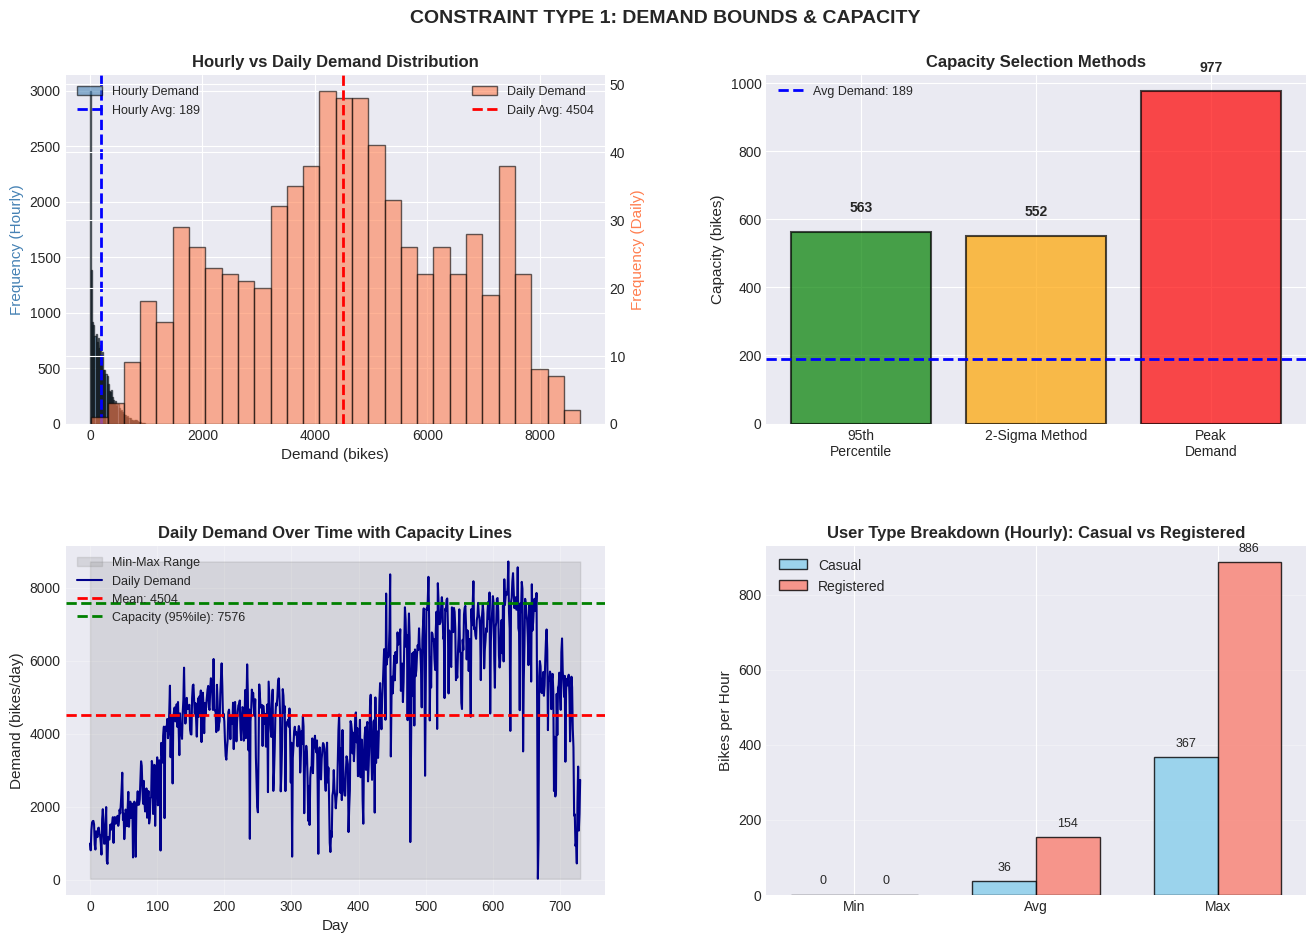

In [41]:
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

fig1 = plt.figure(figsize=(16, 10))
gs1 = GridSpec(2, 2, figure=fig1, hspace=0.35, wspace=0.3)

# 1.1: Hourly vs Daily Demand Distribution
ax1 = fig1.add_subplot(gs1[0, 0])
ax1.hist(
    hour_data["cnt"],
    bins=50,
    alpha=0.6,
    label="Hourly Demand",
    color="steelblue",
    edgecolor="black",
)
ax1_twin = ax1.twinx()
ax1_twin.hist(
    day_data_sorted["cnt"],
    bins=30,
    alpha=0.6,
    label="Daily Demand",
    color="coral",
    edgecolor="black",
)
ax1.axvline(
    avg_hourly_demand,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Hourly Avg: {avg_hourly_demand:.0f}",
)
ax1_twin.axvline(
    avg_daily_demand,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Daily Avg: {avg_daily_demand:.0f}",
)
ax1.set_xlabel("Demand (bikes)", fontsize=11)
ax1.set_ylabel("Frequency (Hourly)", fontsize=11, color="steelblue")
ax1_twin.set_ylabel("Frequency (Daily)", fontsize=11, color="coral")
ax1.set_title("Hourly vs Daily Demand Distribution", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1_twin.legend(loc="upper right", fontsize=9)

# 1.2: Capacity Methods Comparison
capacity_95pct = np.percentile(hour_data["cnt"], 95)
capacity_2sigma = avg_hourly_demand + 2 * std_hourly_demand
capacity_peak = max_hourly_demand

ax2 = fig1.add_subplot(gs1[0, 1])
methods = ["95th\nPercentile", "2-Sigma Method", "Peak\nDemand"]
capacities = [capacity_95pct, capacity_2sigma, capacity_peak]
colors_cap = ["green", "orange", "red"]
bars = ax2.bar(
    methods, capacities, color=colors_cap, alpha=0.7, edgecolor="black", linewidth=1.5
)
ax2.axhline(
    avg_hourly_demand,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Avg Demand: {avg_hourly_demand:.0f}",
)
ax2.set_ylabel("Capacity (bikes)", fontsize=11)
ax2.set_title("Capacity Selection Methods", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
for i, (bar, cap) in enumerate(zip(bars, capacities)):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        cap + 50,
        f"{cap:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# 1.3: Daily Demand with Min/Max/Mean Bands


selected_capacity = np.percentile(day_data["cnt"], 95)
ax3 = fig1.add_subplot(gs1[1, 0])
days = range(len(day_data_sorted))
ax3.fill_between(
    days,
    min_daily_demand,
    max_daily_demand,
    alpha=0.2,
    color="gray",
    label="Min-Max Range",
)
ax3.plot(
    days,
    day_data_sorted["cnt"].values,
    color="darkblue",
    linewidth=1.5,
    label="Daily Demand",
)
ax3.axhline(
    avg_daily_demand,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {avg_daily_demand:.0f}",
)
ax3.axhline(
    selected_capacity,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Capacity (95%ile): {selected_capacity:.0f}",
)
ax3.set_xlabel("Day", fontsize=11)
ax3.set_ylabel("Demand (bikes/day)", fontsize=11)
ax3.set_title(
    "Daily Demand Over Time with Capacity Lines", fontsize=12, fontweight="bold"
)
ax3.legend(fontsize=9, loc="upper left")
ax3.grid(True, alpha=0.3)

# 1.4: User Type Breakdown (Hourly)
ax4 = fig1.add_subplot(gs1[1, 1])
x_pos = [0, 1]
casual_stats = [min_casual, avg_casual, max_casual]
registered_stats = [min_registered, avg_registered, max_registered]
labels_stats = ["Min", "Avg", "Max"]
width = 0.35

for i, (cas, reg, lbl) in enumerate(zip(casual_stats, registered_stats, labels_stats)):
    ax4.bar(
        i - width / 2,
        cas,
        width,
        label="Casual" if i == 0 else "",
        color="skyblue",
        alpha=0.8,
        edgecolor="black",
    )
    ax4.bar(
        i + width / 2,
        reg,
        width,
        label="Registered" if i == 0 else "",
        color="salmon",
        alpha=0.8,
        edgecolor="black",
    )
    ax4.text(
        i - width / 2, cas + 20, f"{cas:.0f}", ha="center", va="bottom", fontsize=9
    )
    ax4.text(
        i + width / 2, reg + 20, f"{reg:.0f}", ha="center", va="bottom", fontsize=9
    )

ax4.set_xticks(range(len(labels_stats)))
ax4.set_xticklabels(labels_stats)
ax4.set_ylabel("Bikes per Hour", fontsize=11)
ax4.set_title(
    "User Type Breakdown (Hourly): Casual vs Registered", fontsize=12, fontweight="bold"
)
ax4.legend(fontsize=10, loc="upper left")
ax4.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "CONSTRAINT TYPE 1: DEMAND BOUNDS & CAPACITY",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.93)
plt.show()


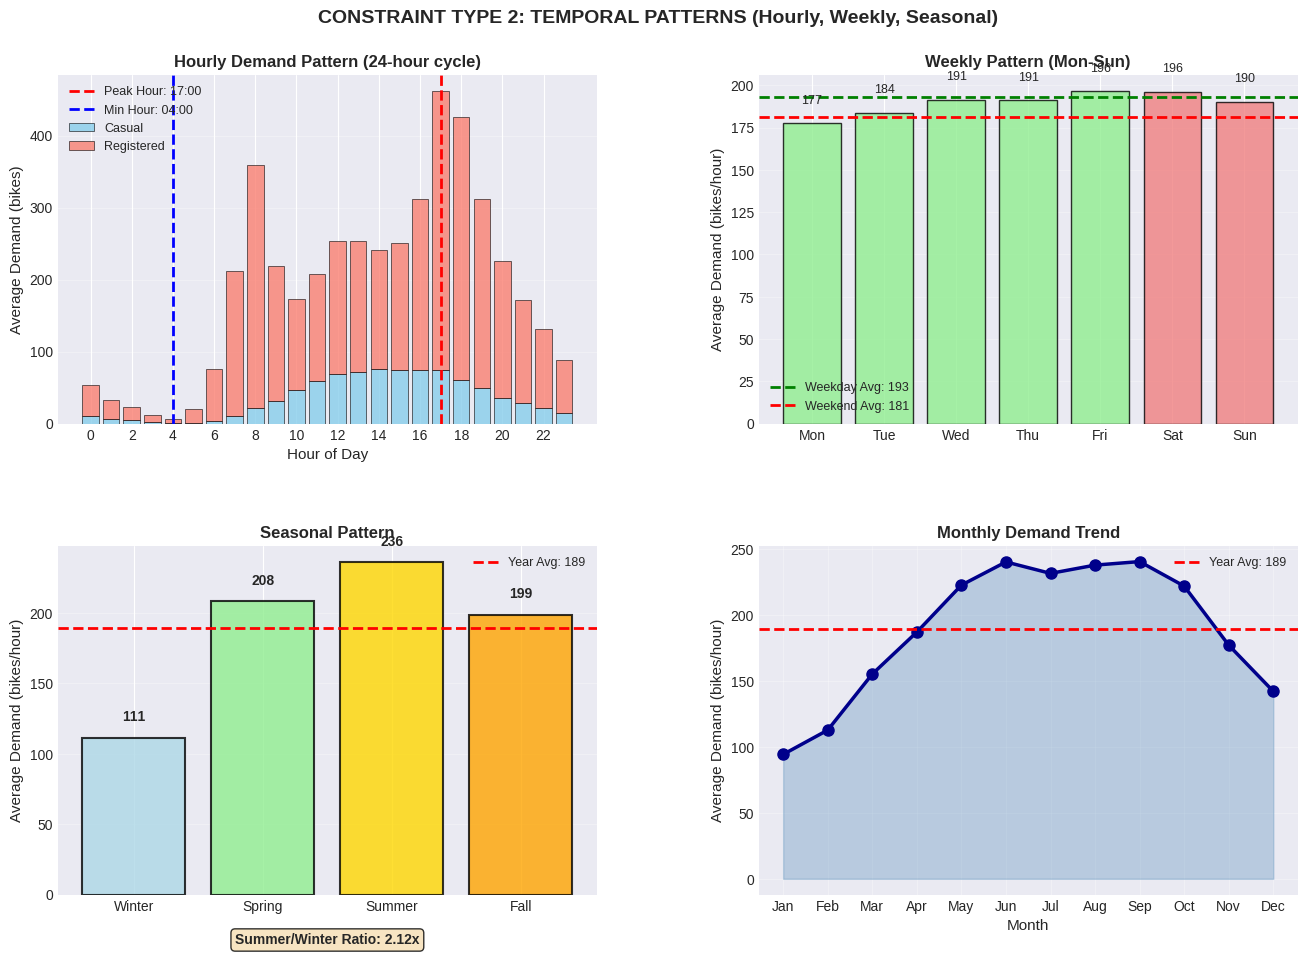

In [42]:
fig2 = plt.figure(figsize=(16, 10))
gs2 = GridSpec(2, 2, figure=fig2, hspace=0.35, wspace=0.3)

# 2.1: Hourly Pattern (Peak Hours)
ax5 = fig2.add_subplot(gs2[0, 0])
hours = range(24)
casual_h = hour_data.groupby("hr")["casual"].mean()
registered_h = hour_data.groupby("hr")["registered"].mean()
hourly_h = hour_data.groupby("hr")["cnt"].mean()

ax5.bar(
    hours,
    casual_h,
    label="Casual",
    color="skyblue",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)
ax5.bar(
    hours,
    registered_h,
    bottom=casual_h,
    label="Registered",
    color="salmon",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)
ax5.axvline(
    peak_hour,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Peak Hour: {int(peak_hour):02d}:00",
)
ax5.axvline(
    min_hour,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Min Hour: {int(min_hour):02d}:00",
)
ax5.set_xlabel("Hour of Day", fontsize=11)
ax5.set_ylabel("Average Demand (bikes)", fontsize=11)
ax5.set_title("Hourly Demand Pattern (24-hour cycle)", fontsize=12, fontweight="bold")
ax5.set_xticks(range(0, 24, 2))
ax5.legend(fontsize=9, loc="upper left")
ax5.grid(True, alpha=0.3, axis="y")

# 2.2: Weekly Pattern (Day of Week)
ax6 = fig2.add_subplot(gs2[0, 1])
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_demand = []
for i in range(7):
    dow_demand.append(hour_data[hour_data["weekday"] == i]["cnt"].mean())

colors_dow = ["lightcoral" if i >= 5 else "lightgreen" for i in range(7)]
bars_dow = ax6.bar(
    dow_names, dow_demand, color=colors_dow, alpha=0.8, edgecolor="black", linewidth=1
)

ax6.axhline(
    weekday_avg,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Weekday Avg: {weekday_avg:.0f}",
)
ax6.axhline(
    weekend_avg,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Weekend Avg: {weekend_avg:.0f}",
)
ax6.set_ylabel("Average Demand (bikes/hour)", fontsize=11)
ax6.set_title("Weekly Pattern (Mon-Sun)", fontsize=12, fontweight="bold")
ax6.legend(fontsize=9)
for bar, demand in zip(bars_dow, dow_demand):
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        demand + 10,
        f"{demand:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax6.grid(True, alpha=0.3, axis="y")

# 2.3: Seasonal Pattern
ax7 = fig2.add_subplot(gs2[1, 0])
season_names = ["Winter", "Spring", "Summer", "Fall"]
season_demands = [seasonal_avg.loc[i, ('cnt', 'mean')] for i in range(1, 5)]
colors_season = ["lightblue", "lightgreen", "gold", "orange"]
bars_season = ax7.bar(
    season_names,
    season_demands,
    color=colors_season,
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
)
ax7.axhline(
    avg_hourly_demand,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Year Avg: {avg_hourly_demand:.0f}",
)
ax7.set_ylabel("Average Demand (bikes/hour)", fontsize=11)
ax7.set_title("Seasonal Pattern", fontsize=12, fontweight="bold")
ax7.legend(fontsize=9)
for bar, demand in zip(bars_season, season_demands):
    ax7.text(
        bar.get_x() + bar.get_width() / 2,
        demand + 10,
        f"{demand:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax7.grid(True, alpha=0.3, axis="y")

# Add ratio annotation
summer_idx = season_names.index("Summer")
winter_idx = season_names.index("Winter")
ratio_text = f"Summer/Winter Ratio: {seasonal_avg.loc[3, ('cnt', 'mean')] / seasonal_avg.loc[1, ('cnt', 'mean')]:.2f}x"
ax7.text(
    0.5,
    -0.15,
    ratio_text,
    transform=ax7.transAxes,
    ha="center",
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    fontsize=10,
    fontweight="bold",
)

# 2.4: Monthly Pattern (continuous)
ax8 = fig2.add_subplot(gs2[1, 1])
monthly_demand = hour_data.groupby("mnth")["cnt"].mean()
ax8.plot(
    range(1, 13),
    monthly_demand.values,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="darkblue",
)
ax8.fill_between(range(1, 13), monthly_demand.values, alpha=0.3, color="steelblue")
ax8.axhline(
    avg_hourly_demand,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Year Avg: {avg_hourly_demand:.0f}",
)
ax8.set_xlabel("Month", fontsize=11)
ax8.set_ylabel("Average Demand (bikes/hour)", fontsize=11)
ax8.set_title("Monthly Demand Trend", fontsize=12, fontweight="bold")
ax8.set_xticks(range(1, 13))
ax8.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.3)

plt.suptitle(
    "CONSTRAINT TYPE 2: TEMPORAL PATTERNS (Hourly, Weekly, Seasonal)",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.93)
plt.show()


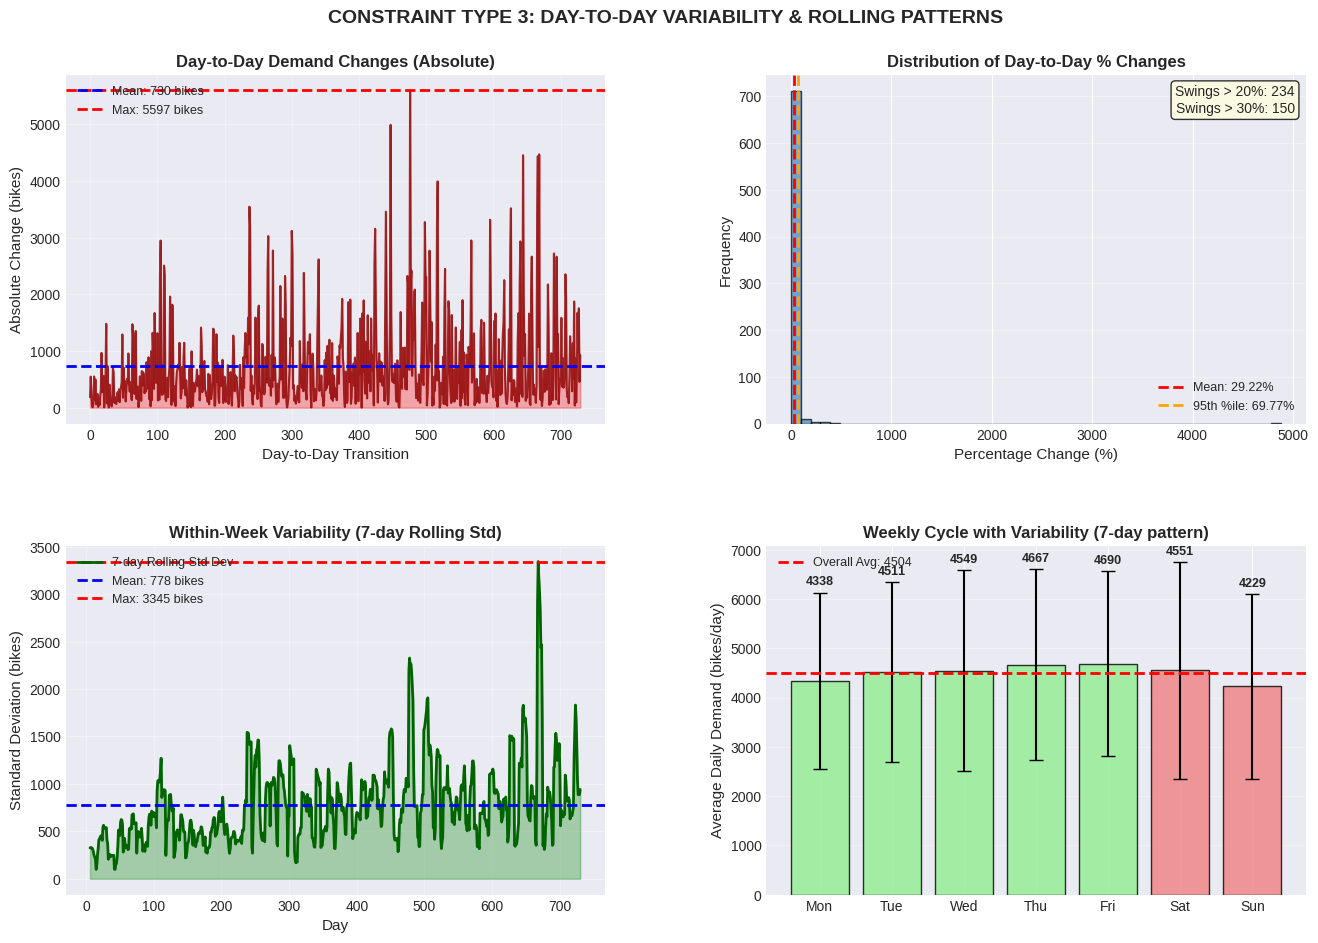

In [43]:
fig3 = plt.figure(figsize=(16, 10))
gs3 = GridSpec(2, 2, figure=fig3, hspace=0.35, wspace=0.3)

# 3.1: Day-to-Day Changes (Absolute)
ax9 = fig3.add_subplot(gs3[0, 0])
ax9.plot(
    range(len(day_to_day_changes)),
    day_to_day_changes,
    color="darkred",
    linewidth=1.5,
    alpha=0.8,
)
ax9.fill_between(
    range(len(day_to_day_changes)), day_to_day_changes, alpha=0.3, color="red"
)
ax9.axhline(
    day_to_day_changes.mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {day_to_day_changes.mean():.0f} bikes",
)
ax9.axhline(
    day_to_day_changes.max(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Max: {day_to_day_changes.max():.0f} bikes",
)
ax9.set_xlabel("Day-to-Day Transition", fontsize=11)
ax9.set_ylabel("Absolute Change (bikes)", fontsize=11)
ax9.set_title("Day-to-Day Demand Changes (Absolute)", fontsize=12, fontweight="bold")
ax9.legend(fontsize=9, loc="upper left")
ax9.grid(True, alpha=0.3)

# 3.2: Day-to-Day Changes (Percentage)
ax10 = fig3.add_subplot(gs3[0, 1])
ax10.hist(pct_changes, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
ax10.axvline(
    pct_changes.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {pct_changes.mean():.2f}%",
)
ax10.axvline(
    np.percentile(pct_changes, 95),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"95th %ile: {np.percentile(pct_changes, 95):.2f}%",
)
ax10.set_xlabel("Percentage Change (%)", fontsize=11)
ax10.set_ylabel("Frequency", fontsize=11)
ax10.set_title("Distribution of Day-to-Day % Changes", fontsize=12, fontweight="bold")
ax10.legend(fontsize=9)
ax10.grid(True, alpha=0.3, axis="y")

# Count large swings
swings_20 = (pct_changes > 20).sum()
swings_30 = (pct_changes > 30).sum()
ax10.text(
    0.98,
    0.97,
    f"Swings > 20%: {swings_20}\nSwings > 30%: {swings_30}",
    transform=ax10.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
    fontsize=10,
)

# 3.3: Rolling 7-day Standard Deviation (Weekly Variability)
ax11 = fig3.add_subplot(gs3[1, 0])
ax11.plot(
    rolling_7d_std.index,
    rolling_7d_std.values,
    color="darkgreen",
    linewidth=2,
    label="7-day Rolling Std Dev",
)
ax11.fill_between(rolling_7d_std.index, rolling_7d_std.values, alpha=0.3, color="green")
ax11.axhline(
    rolling_7d_std.mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {rolling_7d_std.mean():.0f} bikes",
)
ax11.axhline(
    rolling_7d_std.max(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Max: {rolling_7d_std.max():.0f} bikes",
)
ax11.set_xlabel("Day", fontsize=11)
ax11.set_ylabel("Standard Deviation (bikes)", fontsize=11)
ax11.set_title(
    "Within-Week Variability (7-day Rolling Std)", fontsize=12, fontweight="bold"
)
ax11.legend(fontsize=9, loc="upper left")
ax11.grid(True, alpha=0.3)

# 3.4: Weekly Cycle Pattern (by Day of Week)
ax12 = fig3.add_subplot(gs3[1, 1])
dow_names_full = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly_means = []
weekly_stds = []
for dow in range(7):
    dow_data = day_data_sorted[day_data_sorted["dteday"].dt.dayofweek == dow]["cnt"]
    weekly_means.append(dow_data.mean())
    weekly_stds.append(dow_data.std())

ax12.bar(
    dow_names_full,
    weekly_means,
    yerr=weekly_stds,
    capsize=5,
    color=["lightcoral" if i >= 5 else "lightgreen" for i in range(7)],
    alpha=0.8,
    edgecolor="black",
    linewidth=1,
)
ax12.axhline(
    avg_daily_demand,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Avg: {avg_daily_demand:.0f}",
)
ax12.set_ylabel("Average Daily Demand (bikes/day)", fontsize=11)
ax12.set_title(
    "Weekly Cycle with Variability (7-day pattern)", fontsize=12, fontweight="bold"
)
ax12.legend(fontsize=9)
ax12.grid(True, alpha=0.3, axis="y")

for i, (mean, std) in enumerate(zip(weekly_means, weekly_stds)):
    ax12.text(
        i,
        mean + std + 100,
        f"{mean:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.suptitle(
    "CONSTRAINT TYPE 3: DAY-TO-DAY VARIABILITY & ROLLING PATTERNS",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.93)
plt.show()


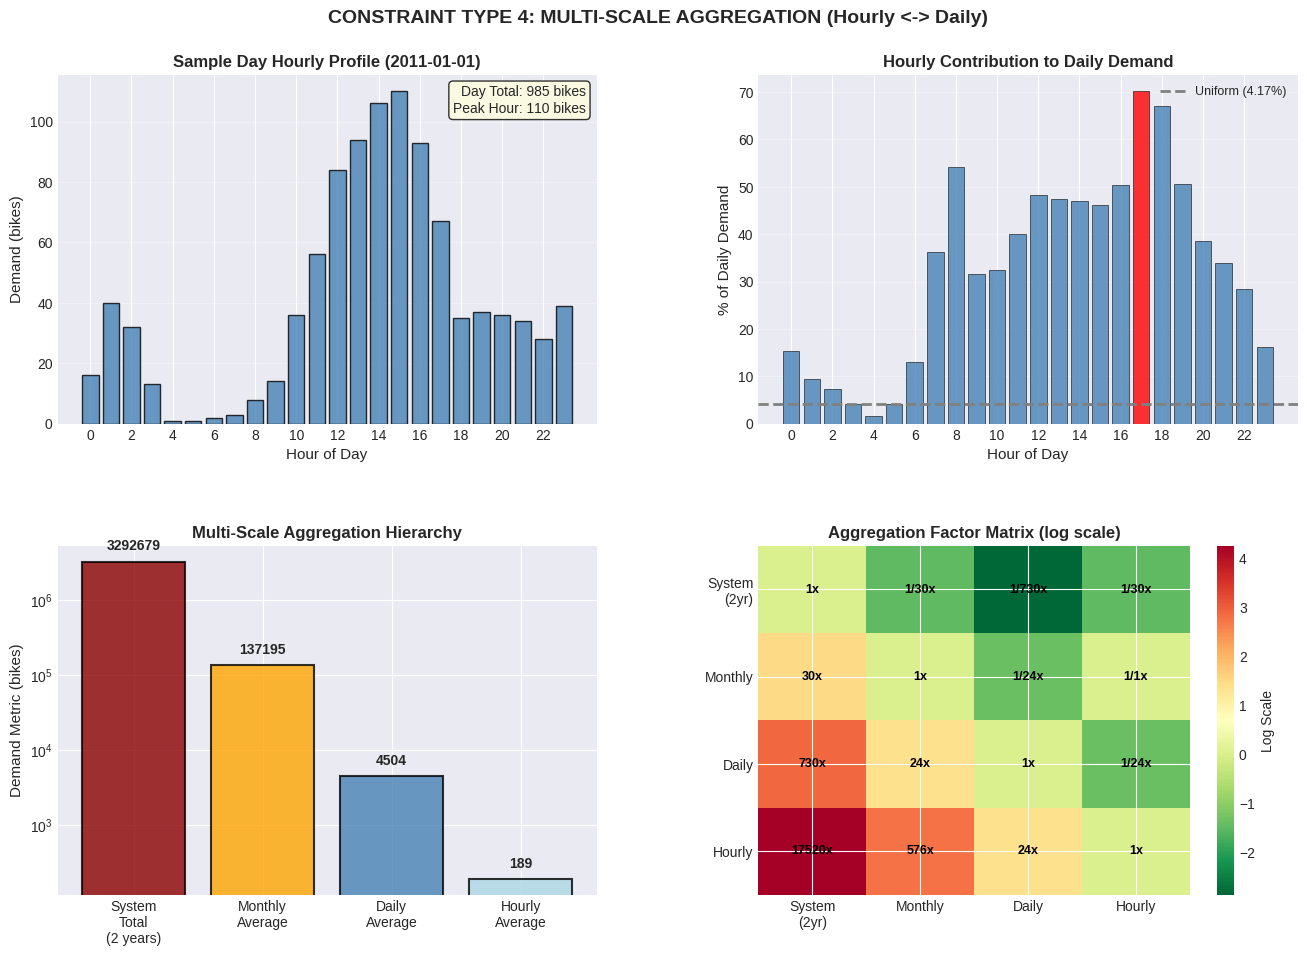

In [44]:
fig4 = plt.figure(figsize=(16, 10))
gs4 = GridSpec(2, 2, figure=fig4, hspace=0.35, wspace=0.3)

# 4.1: Hourly Distribution within a Sample Day
ax13 = fig4.add_subplot(gs4[0, 0])
sample_day = hour_data["dteday"].iloc[0]  # First day
sample_day_data = hour_data[hour_data["dteday"] == sample_day]
if len(sample_day_data) > 0:
    ax13.bar(
        sample_day_data["hr"],
        sample_day_data["cnt"],
        color="steelblue",
        alpha=0.8,
        edgecolor="black",
    )
    ax13.set_ylabel("Demand (bikes)", fontsize=11)
    ax13.set_xlabel("Hour of Day", fontsize=11)
    ax13.set_title(
        f"Sample Day Hourly Profile ({str(sample_day)})", fontsize=12, fontweight="bold"
    )
    ax13.set_xticks(range(0, 24, 2))
    ax13.grid(True, alpha=0.3, axis="y")
    daily_total = sample_day_data["cnt"].sum()
    ax13.text(
        0.98,
        0.97,
        f"Day Total: {daily_total:.0f} bikes\nPeak Hour: {sample_day_data['cnt'].max():.0f} bikes",
        transform=ax13.transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
        fontsize=10,
    )
else:
    ax13.text(0.5, 0.5, "No data available for sample day", ha="center", va="center")

# 4.2: Hourly as % of Daily
ax14 = fig4.add_subplot(gs4[0, 1])
hourly_pct_means = hourly_avg.sum(axis=1) / avg_daily_demand * 100
colors_pct = ["red" if h == peak_hour else "steelblue" for h in range(24)]
bars_pct = ax14.bar(
    range(24),
    hourly_pct_means.values,
    color=colors_pct,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
)
ax14.axhline(
    100 / 24, color="gray", linestyle="--", linewidth=2, label="Uniform (4.17%)"
)
ax14.set_xlabel("Hour of Day", fontsize=11)
ax14.set_ylabel("% of Daily Demand", fontsize=11)
ax14.set_title("Hourly Contribution to Daily Demand", fontsize=12, fontweight="bold")
ax14.set_xticks(range(0, 24, 2))
ax14.legend(fontsize=9)
ax14.grid(True, alpha=0.3, axis="y")

# 4.3: Aggregation Levels (System → Daily → Hourly)
ax15 = fig4.add_subplot(gs4[1, 0])
time_scales = [
    "System\nTotal\n(2 years)",
    "Monthly\nAverage",
    "Daily\nAverage",
    "Hourly\nAverage",
]
time_scale_vals = [
    day_data_sorted["cnt"].sum(),
    day_data_sorted["cnt"].sum() / 24,
    avg_daily_demand,
    avg_hourly_demand,
]
bars_scales = ax15.bar(
    time_scales,
    time_scale_vals,
    color=["darkred", "orange", "steelblue", "lightblue"],
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
)
ax15.set_ylabel("Demand Metric (bikes)", fontsize=11)
ax15.set_title("Multi-Scale Aggregation Hierarchy", fontsize=12, fontweight="bold")
ax15.set_yscale("log")
for bar, val in zip(bars_scales, time_scale_vals):
    ax15.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.3,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# 4.4: Scaling Factors Between Levels
ax16 = fig4.add_subplot(gs4[1, 1])
# Create a heatmap of aggregate relationships
aggregate_matrix = np.array(
    [
        [1, 1 / 30, 1 / 730, 1 / 730 * 24],  # System
        [30, 1, 1 / 24, 1],  # Monthly
        [730, 24, 1, 1 / 24],  # Daily
        [730 * 24, 24 * 24, 24, 1],  # Hourly
    ]
)

levels_labels = ["System\n(2yr)", "Monthly", "Daily", "Hourly"]
im = ax16.imshow(np.log10(aggregate_matrix), cmap="RdYlGn_r", aspect="auto")
ax16.set_xticks(range(4))
ax16.set_yticks(range(4))
ax16.set_xticklabels(levels_labels, fontsize=10)
ax16.set_yticklabels(levels_labels, fontsize=10)
ax16.set_title("Aggregation Factor Matrix (log scale)", fontsize=12, fontweight="bold")

# Add text annotations
for i in range(4):
    for j in range(4):
        if i == j:
            text = "1x"
        else:
            factor = aggregate_matrix[i, j]
            if factor > 1:
                text = f"{factor:.0f}x"
            else:
                text = f"1/{1 / factor:.0f}x"
        ax16.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color="black",
            fontsize=9,
            fontweight="bold",
        )

plt.colorbar(im, ax=ax16, label="Log Scale")

plt.suptitle(
    "CONSTRAINT TYPE 4: MULTI-SCALE AGGREGATION (Hourly <-> Daily)",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.subplots_adjust(hspace=0.35, wspace=0.3, top=0.93)
plt.show()


#### Selected Constraints for Optimization Model



#### 1. Non-Negativity
The demand for any time period must be zero or greater.
$$D_{h}(t) \geq 0, \quad D_{d}(t) \geq 0 \quad \forall t$$
* **Property:** Universal : demand cannot be negative in physical systems.
- $D_{h}(t)$: Hourly Demand at time $t$.
- $D_{d}(t)$: Daily Demand at time $t$.
- $t$: The time index (specific hour or day).
- $\forall t$: A mathematical symbol meaning "for all" time periods $t$.

#### 2. Demand Decomposition by User Type
Total demand is the sum of its constituent segments 
$$D(t) = C_{cas}(t) + R_{reg}(t)$$
* **Property:** Generalizable to any multi-segment demand system.
- $D(t)$: Total Demand at time $t$.
- $C_{cas}(t)$: Demand from Casual Users (unregistered or one-time users).
- $R_{reg}(t)$: Demand from Registered Users (members or subscribers).

#### 3. Temporal Aggregation Consistency
The sum of higher-frequency demand (hourly) must equal the lower-frequency total (daily).
$$\sum_{h=0}^{23} D_{h}(d, h) = D_{d}(d) \quad \forall \text{ day } d$$
* **Property:** A hard structural identity constraint.
- $D_{h}(d, h)$: The demand for a specific hour ($h$) within a specific day ($d$).
- $D_{d}(d)$: The total demand for the entire day ($d$).
- $\sum_{h=0}^{23}$: The summation of all 24 hours (from midnight to 11 PM).

#### 4. Capacity Design : Percentile Method (Non-Parametric)
System capacity is set to cover a specific percentile of historical demand.
$$C \geq P_{k}(D)$$
* **Property:** $P_{k}$ is the $k$-th percentile.
- $C$: The System Capacity (e.g., total bikes or docks available).
- $P_{k}$: The $k$-th Percentile function.
- $D$: The historical Demand dataset.
- $k$: The target coverage level (if $k=95$, capacity meets demand 95% of the time).


#### 5. Capacity Design : Standard Deviation Method
Capacity is defined by the mean demand plus a safety buffer based on variability.
$$C = \mu + k\sigma$$
* **Property:** Based on safety stock theory. $\mu$ = mean, $\sigma$ = standard deviation, and $k$ is the confidence multiplier (1 for 68%, 2 for 95%).
- $\mu$ (mu): The Mean (average) demand over a period.
- $k$: The Safety Factor (multiplier) that determines the confidence level.
- $\sigma$ (sigma): The Standard Deviation, representing the volatility or spread of demand.


#### 6. Logical Day-Type Constraints
Mutual exclusivity between holiday, weekday, and working day status.
$$\text{holiday} = 1 \implies \text{workingday} = 0$$
$$\text{weekday} \in \{0, 6\} \implies \text{workingday} = 0$$
* **Property:** Structurally true for any calendar-based scheduling domain.
- $\text{holiday}$: A binary flag (1 if the day is a public holiday, 0 otherwise).
- $\text{workingday}$: A binary flag (1 if it is a workday, 0 if it is a weekend or holiday).
- $\text{weekday}$: An integer index representing the day of the week (typically 0 for Sunday and 6 for Saturday).


#### 7. Environmental Variable Bounds
Normalized environmental features are constrained to a unit interval.
$$0 \leq \text{temp}, \text{atemp}, \text{hum}, \text{windspeed} \leq 1$$
* **Property:** Defined by the normalization process $[0,1]$.
- $\text{temp}$: Ambient Temperature (actual air temperature).
- $\text{atemp}$: Feeling Temperature (heat index or wind chill).
- $\text{hum}$: Humidity percentage.
- $\text{windspeed}$: Wind speed velocity.

#### 8. Combined Temporal Demand Model (Multiplicative)
Demand is modeled as a baseline hourly profile adjusted by seasonal and weekly factors.
$$D(t, h, w, s) = D_{h}(h) \times f_{w}(w) \times f_{s}(s)$$
* **Property:** $f_{w}$ (weekday) and $f_{s}$ (seasonal) are scaling factors. The functional form is universal.
- $D(t, h, w, s)$: Predicted demand based on time, hour, week, and season.
- $D_{h}(h)$: The Baseline Hourly demand profile.
- $f_{w}(w)$: The Weekly Scaling Factor (adjusts for weekday vs. weekend patterns).
- $f_{s}(s)$: The Seasonal Scaling Factor (adjusts for summer vs. winter patterns).

#### 9. Peak Hour Proportionality
Peak hour demand maintains a stable relationship with total daily demand.
$$D_{h}^{\text{peak}}(t) = P_{\text{peak}} \times D_{d}(t) \quad \forall t$$
* **Property:** $P_{\text{peak}}$ is a coefficient representing the peak-to-daily ratio.
- $D_{h}^{\text{peak}}(t)$: The demand recorded during the busiest hour of the day.
- $P_{\text{peak}}$: The Peak Ratio (the percentage of daily traffic that typically occurs during the peak hour).
- $D_{d}(t)$: The Total Daily demand.

#### 10. Day-to-Day Change Bound
The maximum fluctuation in demand between consecutive days is limited by system logistics.
$$|D_{d}(t) - D_{d}(t-1)| \leq \Delta_{\max}$$
* **Property:** Prevents arbitrary swings that exceed rebalancing or operational capacity.
- $|D_{d}(t) - D_{d}(t-1)|$: The Absolute Difference (magnitude of change) between today's demand and yesterday's demand.
- $\Delta_{\max}$ (Delta max): The Maximum allowable swing or threshold for change.

#### 11. Weekly Rolling Variability
Within-week demand variability is bounded by a minimum and maximum standard deviation.
$$\sigma_{7d, \min} \leq \text{StdDev}(D_{d}(t), \dots, D_{d}(t-6)) \leq \sigma_{7d, \max}$$
* **Property:** Constraints the "stability" of the system over a rolling window.
- $\text{StdDev}(\dots)$: The Standard Deviation calculated over a sliding 7-day window.
- $\sigma_{7d, \min}$: The Minimum expected volatility (prevents the model from assuming "zero" change).
- $\sigma_{7d, \max}$: The Maximum allowed volatility (caps the expected variance).

#### 12. Weekly Summation
Total weekly demand is the aggregate of daily demand over a 7-day period.
$$D_{\text{week}} = \sum_{d=1}^{7} D_{d}(d)$$
* **Property:** Structural aggregation identity for reporting and long-term planning.
- $\text{StdDev}(\dots)$: The Standard Deviation calculated over a sliding 7-day window.
- $\sigma_{7d, \min}$: The Minimum expected volatility (prevents the model from assuming "zero" change).
- $\sigma_{7d, \max}$: The Maximum allowed volatility (caps the expected variance).

